# 4. 밑바닥부터 GPT 모델 구현하기
앞서 LLM 핵심 요소 중 하나인 멀티 헤드 어텐션 메커니즘을 알아보고 구현했다. 이제 다른 LLM 구성 요소를 만들고 조합하여 GPT와 유사한 모델을 만들어 보자. 다음 장에서는 이 모델을 훈련하여 사람이 쓴 거서 같은 텍스트를 생성한다.

## 4.1 LLM 구조 구현하기
GPT와 같은 LLM은 한 번에 하나의 단어(또는 토큰)씩 새로운 텍스트를 생성하도록 고안된 대규모 심층 신경망 구조이다.

입력 토큰화, 임베딩, 마스크드 멀티 헤드 어텐션 모듈과 같은 LLM 구조의 여러 측면을 이미 살펴보았다. 이제 트랜스포머 블록을 비롯해 GPT 모델의 핵심 구조를 구현하고 나중에 사람이 쓴 것 같은 텍스트를 생성하도록 훈련해볼 것이다.

나중에 모델을 구현할 때 사용할 파이썬 딕셔너리로 소규모 GPT-2 모델의 설정을 저장한다.

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, # 어휘사전 크기
    "context_length": 1024, # 문맥 길이
    "emb_dim": 768, # 임베딩 차원
    "n_heads": 12, # 어텐션 헤드 개수
    "n_layers": 12, # 층 개수
    "drop_rate": 0.1, # 드롭아웃 비율
    "qkv_bias": False # 쿼리, 키 값 계산을 위한 편향
}

- n_layers는 모델에 있는 트랜스포머 블록의 개수를 지정한다.

이 설정을 사용해 GPT 더미 클래스(DummyGPTModel)를 구현한다.

다음은 GPT 모델 구현 순서이다.
1. GPT 백본: 전체 모델의 구조를 확인하기 위해 GPT 더미 모델을 만든다.
2. 층 정규화: 그런 다음 2번에서 5번까지 구성 요소를 구현한다.
3. GELU 활성화 함수
4. 피드 포워드 네트워크
5. 숏컷 연결
6. 트랜스포머 블록: 그런 다음 2번에서 5번까지 구성 요소와 3장의 멀티 헤드 어텐션 모듈을 결합하여 트랜스포머 블록을 만든다.
7. 최종 GPT 구조: 마지막으로 여러 개의 트랜스포머 블록을 사용해 훈련하지 않은 GPT 모델을 구현한다.

더미 GPT 백본 모델인 DummyGPTModel을 구현하는 1단계부터 시작한다.

In [2]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])
    self.trf_blocks = nn.Sequential( # 더미 트랜스포머 블록을 사용한다.
        *[DummyTransformerBlock(cfg)
        for _ in range(cfg["n_layers"])]
    )
    self.final_norm = DummyLayerNorm(cfg["emb_dim"]) # 더미 층 정규화를 사용한다.
    self.out_head = nn.Linear(
        cfg["emb_dim"], cfg["vocab_size"], bias = False
    )

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(
        torch.arange(seq_len, device=in_idx.device)
    )
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

class DummyTransformerBlock(nn.Module): # 나중에 실제 트랜스포머 블록으로 교체될 간단한 더미 클래스
  def __init__(self, cfg):
    super().__init__()

  def forward(self, x): # 이 블록은 아무것도 하지않고 입력을 그냥 반환한다.
    return x

class DummyLayerNorm(nn.Module): # 나중에 실제 층 정규화를 위한 층으로 교체될 간단한 더미 클래스
  def __init__(self, normalized_shape, eps=1e-5): # 층 정규화 인터페이스를 흉내내기 위한 매개변수
    super().__init__()

  def forward(self, x):
    return x


위 코드에 있는 DummyGPTModel 클래스는 파이토치의 신경망 모듈(nn.Module)을 사용해 간소화된 GPT 모델을 정의한다. DummyGPTModel 클래스에 구현된 모델은 토큰 임베딩, 위치 임베딩, 일련의 트랜스포머 블록(DummyTransformerBlock), 최종 층 정규화(DummyLayerNorm), 선형 출력 층(out_head)으로 구성된다. 앞서 만든 GPT_CONFIG_124M과 같은 파이썬 딕셔너리를 통해 설정 값을 전달한다.

forward 메서드는 모델을 통과하는 데이터 흐름을 기술한다. 입력 인덱스를 위한 토큰 임베딩과 위치 임베딩을 계산하고, 드롭 아웃을 적용하고, 트랜스포머 블록으로 데이터를 처리하고, 정규화를 적용하고, 최종적으로 선형 출력 층으로 logit(활성함수를 통해 확률로 변하기 전의 출력값)을 생성한다.

그런 다음 입력 데이터를 준비하고 새로운 GPT 모델을 초기화해서 모델 사용법에 대해 알아본다. tiktoken 토크나이저로 GPT 모델에 사용할 2개의 텍스트로 구성된 배치를 토큰화한다.

In [3]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


그런 다음 1억 2,400만 파라미터 크기의 DummyGPTModel 모델을 초기화하고 토큰화된 batch를 주입한다.

In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("출력 크기:", logits.shape)
print(logits)

출력 크기: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


출력 텐서는 2개의 텍스트 샘플에 해당하는 2개의 행을 가진다. 각 텍스트 샘플은 4개의 토큰으로 구성된다. 모델 내부에서 각 토큰은 768차원의 문맥 벡터로 표현되지만, 최종 출력층에서 이 벡터가 어휘사전 크기인 50,257차원의 로짓 벡터로 변환된다.

## 4.2 층 정규화로 활성화 정규화하기
많은 층을 가진 심층 신경망을 훈련하는 것은 그레이디언트 소실이나 그레이디언트 폭주와 같은 문제 때문에 어렵다. 이런 문제로 인해 훈련 과정이 불안정해지고 신경망이 가중치를 효과적으로 조정하기 어렵게 만든다. 이는 훈련 과정에서 손실 함수를 최소화하는 신경망 파라미터(가중치) 집합을 찾기 어렵다는 의미이다. 다른 말로 하면 신경망이 정확한 예측이나 결정을 내리기 위해서 필요한 데이터에 내재된 패턴을 학습하기 어렵다.

그럼 신경망 훈련의 안정성과 효율성을 높이기 위한 층 정규화(layer normalization)를 구현해보자. 층 정규화의 핵심 아이디어는 신경망 층의 활성화(출력)를 평균이 0이고 분산이 1(즉, 단위 분산)이 되도록 조정하는 것이다. 이런 조정이 가중치의 수렴 속도를 높이며 일관되고 안정적인 훈련을 보장한다. GPT-2와 현대적인 트랜스포머 구조에서는 층 정규화가 멀티 헤드 어텐션 모듈 이전과 이후에 적용되며, DummyLayerNorm 클래스에서 보았듯이 최종 출력 층 이전에도 적용된다.

층의 6개 출력(또는 활성화)을 평균이 0이고 분산이 1이 되도록 정규화하는 층 정규화를 구현해보자. 5개의 입력과 6개의 출력을 가진 신경망 층에 2개의 입력 샘플을 적용한다.

In [5]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5) # 5개의 차원(특성)을 가진 2개의 샘플을 만든다.
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


출력된 텐서는 다음과 같다. 첫 번째 행은 첫 번째 입력에 대한 층의 출력이고, 두 번째 행은 두 번째 입력에 대한 층의 출력이다.

이 신경망 층은 하나의 Linear 층과 비선형 활성화 함수인 ReLU로 구성된다. ReLU는 신경망의 표준 활성화 함수로 단순히 음수 입력을 0으로 만들기 때문에 층이 양수 값만 출력하게 만든다. 그래서 층 출력에 음수 값이 하나도 포함되어 있지 않다. 나중에는 GPT에 더 복잡한 다른 활성화 함수를 사용할 것이다.

이 출력에 층 정규화를 적용하기 전에 평균과 분산을 확인해보자.

In [6]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("평균:\n", mean)
print("분산:\n", var)

평균:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
분산:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


평균이나 분산 같은 연산에 keepdim=True를 사용하면 dim 매개변수에 지정된 차원을 따라 텐서가 축소되는 연산이더라고 출력 텐서의 차원이 입력 텐서와 동일하게 유지된다. 예를 들어 keepdim=True를 지정하지 않으면 반환되는 평균 텐서는 2 x 1차원 행렬이 아니라 2차원 벡터 [[0.1324], [0.2170]]가 된다.

그런 다음 앞서 얻은 층 출력에 층 정규화를 적용한다. 이 연산은 입력 값에서 평균을 빼고 분산의 제곱근(즉, 표준편차)으로 나눈다.

In [7]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("정규화된 층 출력:\n", out_norm)
print("평균:\n", mean)
print("분산:\n", var)

정규화된 층 출력:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
평균:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
분산:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


가독성을 위해 sci_mode를 False로 지정하여 텐서를 출력할 때 과학적 표기법을 사용하지 않을 수도 있다.

In [8]:
torch.set_printoptions(sci_mode=False)
print("평균:\n", mean)
print("분산:\n", var)

평균:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
분산:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


지금까지 층 정규화를 단계별로 구현하여 적용해 보았다. 이제 나중에 GPT 모델에서 사용할 수 있도록 파이토치 모듈로 이 과정을 캡슐화 해보자.

In [9]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5 # 정규화할 때 0 나눗셈을 방지하기 위해 분산에 더해지는 작은 상수
    self.scale = nn.Parameter(torch.ones(emb_dim)) # scale과 shift는 입력과 차원이 동일한 훈련 가능한 파라미터
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x-mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

In [10]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("평균:\n", mean)
print("분산:\n", var)

평균:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
분산:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


다음으로는 LLLM에서 전통적인 ReLU 함수 대신 사용되는 활성화 함수인 GELU 함수를 살펴볼 것이다.

## 4.3 GELU 활성화 함수를 사용하는 피드포워드 네트워크 구현하기
다음으로 LLM의 트랜스포머 블록에서 사용되는 신경망 하위 모듈을 구현한다. 신경망 하위 모듈에서 중요한 역할을 담당하는 GELU 활성화 함수부터 구현해보자.



In [11]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) *
        (x + 0.044715 * torch.pow(x, 3))
    ))

GELU 함수와 ReLU 함수를 비교해 보기 위해 두 함수를 나란히 그려 보자.

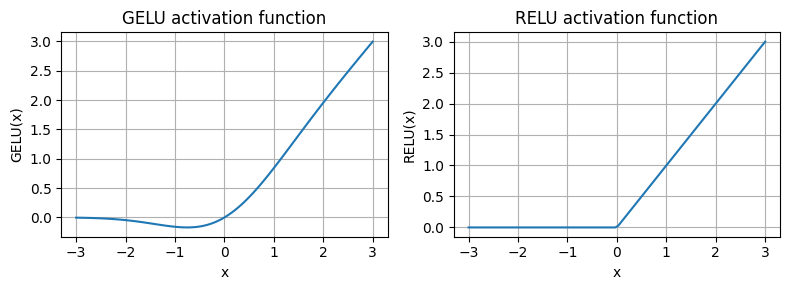

In [12]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100) # -3~3 사이에서 100개의 데이터 포인트를 만든다.
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8,3))
for i, (y,label) in enumerate(zip([y_gelu, y_relu], ["GELU", "RELU"]), 1):
  plt.subplot(1, 2, i)
  plt.plot(x, y)
  plt.title(f"{label} activation function")
  plt.xlabel("x")
  plt.ylabel(f"{label}(x)")
  plt.grid(True)
plt.tight_layout()
plt.show()

그림에서 볼 수 있듯이 ReLU(오른쪽)는 양수는 그래도 출력하고 음수는 모두 0을 출력하는 구간별 선형 함수이다. GELU(왼쪽)는 부드러운 비선형 함수로, ReLU와 비슷하지만 모든 음수 값의 그레이디언트를 0으로 만들지 않는다. (대략 x = -0.75에서는 그레이디언트가 0이 된다.)

이제 GELU 함수를 사용해 LLM 트랜스포머 블록에 사용할 작은 신경망 모듈인 FeedForward를 구현해 보자.

In [13]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
        GELU(),
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
    )

  def forward(self, x):
    return self.layers(x)

여기에서 보듯이 FeedForward 모듈은 2개의 Linear 층과 하나의 GELU 활성화 함수로 구성된 작은 신경망이다. 1억 2,400만 파라미터를 가진 GPT 모델의 경우 임베딩 크기가 768인 토큰으로 구성된 입력 배치를 받는다. 이 값은 GPT_CONFIG_124M 딕셔너리에 GPT_CONFIG_124M["emb_dim"] = 768과 같이 정의되어 있다.

토큰 임베딩 크기를 768로 하여 새로운 FeedForward 모듈을 초기화해보자. 그런 다음 2개의 샘플과 각각 3개의 토큰을 가진 배치 입력을 전달한다.

In [14]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


FeedForward 모듈은 데이터에서 학습하고 일반화하는 모델의 능력을 향상하는 데 중요한 역할을 한다. 이 모듈의 입력 차원과 출력 차원이 같지만 내부적으로 첫 번째 선형 층에서 임베딩 차원을 고차원 공간으로 확장한다. 이렇게 확장된 다음에 비선형 GLEU 함수가 뒤따르고 두 번째 선형 변환을 통해 원본 차원으로 축소된다.

다음으로 서로 다른 신경망 층 사이에 추가하는 숏컷 연결의 개념을 알아보자. 심층 신경망 구조에서 훈련 성능을 향상하기 위해 매우 중요한 기법이다.


## 4.4 숏컷 연결 추가하기
스킵 연결(skip connection), 잔차 연결(residual connection)이라고도 불리는 숏컷 연결(shortcut connection)의 개념을 알아보자. 원래 숏컷 연결은 컴퓨터 비전 분야의 심층 신경망에서 그레이디언트 소실 문제를 완화하기 위해 제안되었다. 그레이디언트 소실 문제는 그레이디언트가 층을 거듭해 역전파되면서 점진적으로 작아져 앞쪽 층을 효과적으로 훈련하기 어려워지는 현상을 나타낸다.

숏컷 연결은 그레이디언트가 1개 이상의 층을 건너뛰어 네트워크에 흐를 수 있도록 짧은 다른 경로를 만든다. 이런 경로는 한 층의 출력을 이후 층의 출력에 더함으로써 만들어진다. 그래서 이런 연결을 스킵 연결이라고도 부른다. 훈련할 때 역전파 과정에서 그레이디언트 흐름을 보존하는 데 중요한 역할을 한다.

forward 메서드에서 숏컷 연결을 추가해보자.

In [15]:
class ExampleDeepNeuralNetwork(nn.Module):
  def __init__(self, layer_sizes, use_shortcut):
    super().__init__()
    self.use_shortcut = use_shortcut
    self.layers = nn.ModuleList([ # 5개의 층을 만든다
        nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]),
                      GELU()),
        nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]),
                      GELU()),
        nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]),
                      GELU()),
        nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]),
                      GELU()),
        nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]),
                      GELU()),
    ])

  def forward(self, x):
    for layer in self.layers:
      layer_output = layer(x) # 현재 층의 출력을 계산한다
      if self.use_shortcut and x.shape == layer_output.shape: # 숏컷 연결을 적용할 수 있는지 확인
        x = x + layer_output
      else:
        x = layer_output
    return x

이 코드는 5개의 층으로 구성된 신경망을 만든다. 각 층은 Linear 층과 GELU 활성화 함수로 구성된다. 정방향 계산에서 입력을 반복해서 층에 통과시키고 self.use_shortcut 속성이 True이면 선택적으로 숏컷 연결을 추가한다.

이 코드를 사용해 숏컷 연결이 없는 신경망을 초기화해 보자. 각 층은 3개의 입력 값을 가진 샘플을 받아 3개의 출력 값을 반환한다. 마지막 층은 하나의 값을 반환한다.

In [16]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)

그런 다음 모델의 역전파에서 그레이디언트를 계산하는 함수를 구현한다.

In [17]:
def print_gradients(model, x):
  output = model(x) # 정방향 계산
  target = torch.tensor([[0.]])

  loss = nn.MSELoss()
  loss = loss(output, target) # 타깃과 출력의 가까운 정도를 기반으로 손실을 계산한다.

  loss.backward() # 그레이디언트 계산을 위한 역전파
  for name, param in model.named_parameters():
    if 'weight' in name:
      print(f"{name}의 평균 그레이디언트는 {param.grad.abs().mean().item()}입니다.")

이 코드는 모델 출력이 사용자가 지정한 타깃(여기서는 간단하게 0)에 얼마나 가까운지 계산하는 손실 함수를 정의한다. 그런 다음 loss.backward()를 호출하면 파이토치가 모델의 각 층에서 손실 그레이디언트를 계산한다. model.named_parameters()를 통해 가중치 파라미터를 순회할 수 있다. 어떤 층에 3 x 3 크기의 가중치 파라미터 행렬이 이다고 가정해 보자. 이 경우 이 층은 3 x 3 크기의 그레이디언트 값을 가진다. 각 층의 그레이디언트를 비교하기 쉽도록 3 x 3 크기의 그레이디언트 값의 절댓값을 평균하여 하나의 그레이디언트 값을 출력한다.

그럼 print_gradients 함수를 숏컷 연결이 없는 모델에 적용해보자.

In [18]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight의 평균 그레이디언트는 0.00020173584925942123입니다.
layers.1.0.weight의 평균 그레이디언트는 0.00012011159560643137입니다.
layers.2.0.weight의 평균 그레이디언트는 0.0007152040489017963입니다.
layers.3.0.weight의 평균 그레이디언트는 0.0013988736318424344입니다.
layers.4.0.weight의 평균 그레이디언트는 0.005049645435065031입니다.


print_gradients 함수의 출력을 보면 마지막 층(layers.4)에서 첫 번째 층(layers.0)으로 갈수록 그레이디언트가 점점 작아진다. 이런 현상을 **그레이디언트 소실 문제**가 부른다.

그럼 숏컷 연결을 가진 모델을 만들어서 비교해 보자.

In [19]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut = True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight의 평균 그레이디언트는 0.22169791162014008입니다.
layers.1.0.weight의 평균 그레이디언트는 0.20694105327129364입니다.
layers.2.0.weight의 평균 그레이디언트는 0.32896995544433594입니다.
layers.3.0.weight의 평균 그레이디언트는 0.2665732204914093입니다.
layers.4.0.weight의 평균 그레이디언트는 1.3258540630340576입니다.


마지막 층이 여전히 다른 층보다 그레이디언트 값이 크다. 하지만 첫 번쨰 층으로 갈수록 그레이디언트 값이 안정적이고 아주 작은 값으로 줄어들지 않는다.

다음으로 이 장에서 다룬 모든 개념(층 정규화, GELU 활성화 함수, 피드 포워드 신경망, 숏컷 연결)을 GPT 모델을 만드는 데 필요한 최종 구성 요소인 트랜스포머 블록 하나로 결합한다.

## 4.5 어텐션과 선형 층을 트랜스포머 블록에 연결하기
이제 GPT와 다른 LLM 구조의 기본 구성 요소인 트랜스포머 블록을 구현해보자. 1억 2,400만개의 파라미터를 가진 GPT-2 모델에서는 이 블록이 12번 반복되며, 이전에 다룬 여러 개념(멀티 헤드 어텐션, 층 정규화, 드롭아웃, 피드 포워드 신경망, GELU 활성화 함수, 숏컷 연결)을 복합적으로 사용한다.

멀티 헤드 어텐션 블록에 있는 셀프 어텐션 메커니즘은 입력 시퀀스에 있는 원소 사이에 있는 관계를 식별하고 분석한다. 반대로 피드 포워드 신경망은 각 위치의 데이터를 개별적으로 변환한다. 이런 조합을 통해 입력을 이해하고 처리하는 것뿐만 아니라 복잡한 데이터 패턴을 처리하기 위해 모델의 전반적인 용량을 향상시킨다.

In [20]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out,
               context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert(d_out % num_heads ==0) , \
        "d_out은 num_heads로 나누어 떨어져야 합니다"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    # 텐서 크기: (b, num_tokens, d_out)
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    # num_heads 차원을 추가함으로써 암묵적으로 다음 행렬을 분할한다.
    # 그런 다음 마지막 차원을 num_heads에 맞춰 채운다.
    # (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

    # (b, num_tokens, num_heads, head_dim) 크기를
    # (b, num_heads, num_tokens, head_dim)로 바꾼다.
    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)

    # 각 헤드에 대해 점곱을 수행한다.
    attn_scores = queries @ keys.transpose(2, 3)
    # 토큰 개수로 마스크를 자른다.
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

    # 마스크를 사용해 어텐션 점수를 채운다.
    attn_scores.masked_fill_(mask_bool, -torch.inf)

    attn_weigths = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weigths)

    # 텐서 크기: (b, num_tokens, num_heads, head_dim)
    context_vec = (attn_weights @ values).transpose(1, 2)

    # 헤드를 결합한다. self.d_out = self.num_heads * self.head_dim
    context_vec = context_vec.contiguous().view(
        b, num_tokens, self.d_out
    )

    # 선형 투영을 추가한다.
    context_vec = self.out_proj(context_vec)
    return context_vec

In [21]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.att = MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_length=cfg["context_length"],
        dropout=cfg["drop_rate"],
        num_heads=cfg["n_heads"],
        qkv_bias=cfg["qkv_bias"]
    )
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self, x):
    shortcut = x # 어텐션 블록을 위한 숏컷 연결
    x = self.norm1(x)
    x = self.att(x)
    x = self.drop_shortcut(x)
    x = x + shortcut # 원본 입력을 더한다

    shortcut = x # 피드 포워드 신경망을 위한 숏컷 연결
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_shortcut(x)
    x = x + shortcut # 원본 입력을 더한다.
    return x

이 코드는 파이토치로 TransformerBlock 클래스를 정의한다. 멀티 헤드 어텐션 메커니즘과 피드 포워드 신경망이 포함되며, GPT_CONFIG_124M과 같은 설정 딕셔너리(cfg)를 기반으로 만들어진다.

층 정규화는 이 두 구성 요소 앞에 적용되고, 드롭아웃은 모델을 규제하고 과대적합을 막기 위해 두 구성 요소 후에 적용된다. 이를 **사전 층 정규화(Pre-LayerNorm)**라 부른다. 원본 트랜스포머 모델과 같은 예전 구조에서는 셀프 어텐션과 피드 포워드 신경망 다음에 층 정규화를 적용했다. 이를 **사후 층 정규화(Post-LayerNorm)**라고 한다.

앞서 정의한 GPT_CONFIG_124M 딕셔너리를 사용해 트랜스포머 블록을 초기화하고 샘플 데이터를 전달해보자.

In [22]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("입력 크기:", x.shape)
print("출력 크기:", output.shape)

입력 크기: torch.Size([2, 4, 768])
출력 크기: torch.Size([2, 4, 768])


여기서 보듯이 트랜스포머 블록은 입력 차원과 출력 차원을 동일하게 유지한다. 트랜스포머 구조가 신경망을 통과하는 시퀀스 데이터의 크기를 바꾸지 않고 처리한다는 의미이다.

트랜스포머 블록에서 크기를 보존하는 것은 우연이 아니며 중요한 설계 고려 사항이다. 이를 통해 출력 벡터가 입력 벡터에 일대일 관계로 대응되는 다양한 시퀀스-투-시퀀스 작업에 효과적으로 적용할 수 있다. 출력은 전체 입력 시퀀스의 정보를 담은 문맥 벡터이다. 시퀀스의 물리적 차원(길이와 특성 크기)은 트랜스포머 블록을 통과하면서 바뀌지 않고 동일하지만, 출력 벡터 내용은 전체 입력 시퀀스의 문맥 정보를 통합하도록 재인코딩 된다는 의미이다.

## 4.6 GPT 모델 만들기
이 장을 시작할 때 DummyGPTModel 클래스로 GPT 구조의 큰 그림을 그려 보았다. DummyGPTModel 구현에서 GPT 모델의 입력과 출력을 보여 주었지만, 중요 구성 요소는 DummyTransformerBlock과 DummyLayerNorm 클래스를 사용해 블랙 박스로 남겨 두었다.

이제 DummyTransformerBlock과 DummyLayerNorm을 1억 2,400만 파라미터를 가진 GPT-2 원본 버전을 구현하기 위해 만든 TransformerBlock과 LayerNorm 클래스로 바꾸어 보자.

In [23]:
from numpy import shape
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )

    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
        cfg["emb_dim"], cfg["vocab_size"], bias=False
    )

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)

    pos_embeds = self.pos_emb(
        torch.arange(seq_len, device=in_idx.device)
    )
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits


GPTModel 클래스의 __init__ 생성자는 파이썬 딕셔너리 cfg로 전달된 설정을 사용해 토큰 임베딩 층과 위치 임베딩 층을 초기화한다. 이 임베딩 층은 토큰 인덱스를 밀집 벡터로 변환하고 위치 정보를 추가하는 역할을 담당한다.

다음으로 __init__ 메서드는 cfg에 지정된 층 개수만큼 TransformerBlock 모듈의 시퀀셜 스택을 만든다. 트랜스포머 블록 다음에 훈련 과정을 안정화하기 위해 트랜스포머 블록의 출력을 정규화하는 LayerNorm 층을 정의한다. 마지막으로 트랜스포머 블록의 출력을 토크나이저의 어휘사전 공간에 투영하여 어휘사전에 있는 각 토큰에 대한 로짓을 생성하기 위해 편향이 없는 선형 출력 헤드를 정의한다.

forward 메서드는 입력 토큰 인덱스의 배치를 받아, 임베딩을 계산하고, 위치 임베딩을 적용하고, 트랜스포머 블록에 통과시키고, 최종 출력을 정규화하고, 로짓을 계산한다. 로짓은 다음 토큰에 대한 정규화되지 않은 확률을 나타낸다. 다음 절에서 이 로짓을 토큰과 텍스트 출력으로 변환한다.

- 처음:
토큰 번호 → 토큰을 이해하기 위한 768차원 표현

- 마지막:
768차원 문맥 표현 → 다음 토큰을 고르기 위한 50,257개 점수

이제 GPT_CONFIG_124M 딕셔너리를 cfg 매개변수에 전달하여 1억 2,400만 파라미터를 가진 GPT 모델을 초기화하고, 이전에 만든 배치 텍스트 입력을 주입해본다.

In [24]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)

print("입력 배치:\n", batch)
print("\n출력 크기:", out.shape)
print(out)

입력 배치:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

출력 크기: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


여기서 보듯이 각각 4개의 토큰을 가진 2개의 입력 텍스트를 전달했기 때문에 출력 텐서의 크기는 [2, 4, 50257]이다. 마지막 차원인 50257은 토크나이저의 어휘사전 크기에 해당한다. 나중에 50,257차원의 출력 벡터를 토큰으로 변환하는 방법을 알아보자.

모델의 출력을 텍스트로 변환하는 함수를 만들기 전에 잠시 모델 구조를 살펴보고 크기를 분석해보자. numel() 메서드를 사용해 모델 파라미터 텐서에 있는 총 파라미터 개수를 확인할 수 있다.

In [25]:
total_params = sum(p.numel() for p in model.parameters())
print(f"총 파라미터 개수: {total_params:,}")

총 파라미터 개수: 163,009,536


앞서 1억 2,400만 파라미터를 가진 GPT 모델을 만든다고 했는데 왜 실제 파라미터 개수가 1억 6,300만개일까?

그 이유는 원본 GPT-2 구조에 사용된 **가중치 묶기**라는 개념 때문이다. 원본 GPT-2 구조는 토큰 임베딩 층의 가중치를 출력 층에 재사용한다.

이제 이 출력 텐서를 텍스트로 변환하는 코드를 작성해보자.

## 4.7 텍스트 생성하기
이제 GPT 모델의 텐서 출력을 텍스트로 변환하는 코드를 구현해보자.

"Hello, I am"과 같은 입력 문맥이 주어졌을 때 GPT 모델이 텍스트를 생성하는 단계별 과정은 다음과 같다.
1. 텍스트 입력을 토큰 ID로 인코딩한다.
2. GPT 모델은 4개의 벡터(행)와 각 벡터가 50,257차원(열)으로 구성된 행렬을 반환한다.
3. GPT 모델이 생성할 다음 토큰에 해당하는 마지막 벡터를 추출한다.
4. 소프트맥스 함수를 사용해 로짓을 확률 분포로 변환한다.
5. 가장 큰 값의 인덱스 위치(토큰ID)를 찾는다. 가장 큰 원소의 위치가 257이라면 토큰 ID 257을 얻게 된다. 토큰 ID롤 텍스트 "a"로 인코딩한다.
6. 다음 라운드를 위해 이 토큰을 이전 입력에 추가한다.

각 반복에서 모델은 가능성 있는 다음 토큰을 표현하는 벡터를 담은 행렬을 출력한다. 다음 토큰에 해당하는 벡터를 추출하고 softmax 함수를 이용해 확률 분포로 변환한다. 확률 점수를 담은 벡터에서 가장 큰 값의 인덱스를 확인하여 토큰 ID로 해석한다. 이 토큰 ID를 텍스트로 디코딩하여 시퀀스의 다음 토큰으로 출력한다. 마지막으로 이 토큰을 이전 입력에 추가하여 이후 반복을 위한 새로운 입력 시퀀스를 만든다. 이런 단계별 과정을 통해 모델이 초기 입력 문맥으로부터 순차적으로 텍스트를 생성하여 일관성 있는 구문과 문장을 만든다.

토큰 생성 과정은 다음과 같이 구현할 수 있다.

In [26]:
def generate_text_simple(model, idx, # idx는 현재 문맥이 담긴 (batch, num_tokens) 크기의 인덱스 배열이다
                         max_new_tokens, context_size):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:] # 현재 문맥이 모델이 지원하는 문맥 크기를 초과하면 잘라낸다. 예를 들어 LLM이 5개 토큰만 지원하고 문맥 크기가 10이라면, 마지막 5개 토큰만 문맥으로 사용한다
    with torch.no_grad():
      logits = model(idx_cond)

    logits = logits[:, -1, :] # 마지막 타임 스텝만 사용하므로 (batch, num_tokens, vocab_size)가 (batch, vocab_size)가 된다
    probas = torch.softmax(logits, dim=-1) # probas 크기는 (batch, vocab_size)이다
    idx_next = torch.argmax(probas, dim=-1, keepdim=True) # idx_next의 크기는 (batch, 1)이다
    idx = torch.cat((idx, idx_next), dim=1) # 선택한 인덱스를 현재 시퀀스에 추가하므로 idx의 크기는 (batch, num_tokens+1)가 된다

  return idx

이 코드는 파이토치를 사용해 언어 모델의 생성 루프를 간단히 구현한 것이다. 지정한 토큰 생성 횟수를 반복하고, 모델의 최대 문맥 크기에 맞게 현재 문맥을 잘라내고, 예측을 계산하고, 가장 높은 확률 값을 기반으로 다음 토큰을 선택한다.

generate_text_simple 함수에서 softmax 함수를 사용해 로짓을 확률 분포로 바꾼 다음, torch.argmax로 가장 높은 값을 가진 위치를 찾는다. softmax 함수는 단조 함수이므로 입력의 크기 순서가 출력에 그대로 보존된다. 즉, softmax 함수의 출력 텐서에서 가장 큰 값의 위치가 로짓 텐서에서 가장 큰 값의 위치와 동일하다. 이를 통해 모델이 가장 가능성 있는 토큰을 샘플링하는 그리디 디코딩(greedy decoding)에 대해 설명할 수 있다.

다음 장에서 GPT 훈련 코드를 구현할 때는 모델이 항상 가장 가능성이 높은 토큰을 선택하지 않도록 softmax 출력을 조정하는 다른 샘플링 기법을 사용할 것이다. 이를 통해 생성된 텍스트에 다양성과 창의성을 부여할 수 있다.

이제 "Hello, I am" 문맥을 모델의 입력으로 사용해 generate_text_simple 함수를 테스트해보자. 먼저 입력 문맥을 토큰 ID로 인코딩한다.

In [27]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("인코딩된 ID:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0) # 배치 차원을 추가한다
print("encoded_tensor.shape:", encoded_tensor.shape)

인코딩된 ID: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


다음으로 모델을 .eval() 모드로 바꾼다. 이는 훈련 과정에서만 사용되는 드롭아웃 같은 확률적인 구성 요소를 끈다. 인코딩된 입력 텐서로 generate_text_simple 함수를 호출한다.

In [28]:
model.eval() # 모델 훈련이 아니므로 드롭아웃을 끈다.
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("출력:", out)
print("출력 길이:", len(out[0]))

출력: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
출력 길이: 10


토크나이저의 .decode 메서드를 사용해 ID를 텍스트로 변환할 수 있다.

In [29]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


여기서 볼 수 있듯이 모델은 "Hello, I am a model ready to help."와 같은 일관성 있는 텍스트를 생성하지 못한다. 모델이 일관성 있는 텍스트를 생성하지 못하는 이유는 아직 훈련되지 않았기 때문이다. 지금까지 GPT 구조를 구현하고 랜덤한 초기 가중치로 GPT 모델 객체만 만들었다. 모델 훈련은 큰 주제이므로 다음 장에서 다룬다.